# 08 - Latent-space 3DVar (PCA-32 / AE-32 / VAE-32)

The same offline 3DVar as notebook 07, run on a 32-dim learned representation instead
of the 4096-dim pixel field. The state and its covariance `B_z` live in latent space;
the observations, `R`, and the innovation stay in pixel/anomaly degC; the observation
operator is `H = decode . select`. PCA's decoder is affine so the closed-form gain
applies (`LinearLatentVar`); the AE/VAE decoders are linearised to their tangent about
`z_clim` for the same one-step latent gain (`TangentLinearLatentVar`). Posterior
uncertainty is the linearised pixel diagonal, and reconstructions are re-centred so the
climatological background is the zero-anomaly field.

Outputs go to `outputs/da/3dvar_{pca,ae,vae}/` with the same schema as the pixel runs
(a `space` column tags pixel vs latent), so notebook 09 compares them directly.
Background is climatological only (it beat per-age in pixel space).

In [1]:
%load_ext autoreload
%autoreload 2

# Cap BLAS threading before numpy loads. The latent assimilation runs thousands of small
# (~130x130) eigendecompositions per lane, a size where splitting each one across cores
# costs far more in thread setup than it saves; left uncapped it also saturates a shared
# machine. These variables are read only when numpy first initialises, so they have to be
# set above the numpy import. The compressors run on DEVICE, so this leaves them alone.
import os

for _var in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
             "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"):
    os.environ[_var] = "1"

import shutil
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

sys.path.insert(0, os.path.abspath(".."))

from paleoreco.data import build_prior_cube, VARS
from paleoreco.data.cube import apply_anomaly, compute_zscore_stats
from paleoreco.data.splits import chronological_half_split
from paleoreco.assim.observations import (
    attach_site_stats, collapse_to_samples, load_observations, observation_site_stats,
)
from paleoreco.assim.compressors import AECompressor, PCACompressor, VAECompressor, latent_prior
from paleoreco.assim.latent import latent_var
from paleoreco.assim import experiments as ex
from paleoreco.eval.shared import compute_E_d, pod_fit
from paleoreco.models.autoencoder import ConvAE, ConvBetaVAE

plt.rcParams["figure.dpi"] = 110
DATA = "../data"
OUT = Path("../outputs/da")
CKPT = Path("../outputs/checkpoints")
FIG = Path("../outputs/figures/08_latent_3dvar")
FIG.mkdir(parents=True, exist_ok=True)

DEVICE = ("cuda" if torch.cuda.is_available()
          else "mps" if torch.backends.mps.is_available() else "cpu")
print("device:", DEVICE)

# The cap fails silently if numpy was already imported, so time the operation it
# protects: ~2 ms per call means capped, tens of ms means it did not take effect.
_a = np.random.default_rng(0).normal(size=(130, 130))
_a = _a @ _a.T
_t0 = time.perf_counter()
for _ in range(5):
    np.linalg.eigh(_a)
print(f"eigh(130x130): {1e3 * (time.perf_counter() - _t0) / 5:.1f} ms/call "
      f"(~2 ms expected with threads capped)")

device: cuda
eigh(130x130): 1.2 ms/call (~2 ms expected with threads capped)


## Prior cube, chronological split, observation network

Two lanes with different holdout rules need two latent priors. The same-model PPE holds
out the younger half of the cube, so its compressor, anomaly frame, and `B_z` come from
the older half alone (`prior_idx`). The withholding lane holds out real proxies rather
than model states, so every age is legitimately available to it (`all_idx`). Each frame
carries its own climatology and `safe_valid`, so a compressor is only ever paired with
the frame it was fit in.

In [2]:
P = build_prior_cube(prior_csv=f"{DATA}/Prior.csv", cache_path=f"{DATA}/cache/prior_cube.npz")
cube, ages, lats, lons, valid = P["cube"], P["ages"], P["lats"], P["lons"], P["valid"]
SHAPE = (len(VARS), len(lats), len(lons))
TRUTH_STRIDE = 10                        # passed to run_ppe, so truth_idx matches the truths it scores

all_idx = np.arange(len(ages))
prior_idx, truth_idx = chronological_half_split(ages, stride=TRUTH_STRIDE)

stats_all = compute_zscore_stats(cube, all_idx, valid)
cube_anom_all = apply_anomaly(cube, stats_all)
safe_all = stats_all["safe_valid"]

stats_a = compute_zscore_stats(cube, prior_idx, valid)
cube_anom_a = apply_anomaly(cube, stats_a)
safe_a = stats_a["safe_valid"]

long_ppe = load_observations(f"{DATA}/Observation.csv")
long_wh = attach_site_stats(long_ppe, observation_site_stats(collapse_to_samples(long_ppe)))

print(f"cube {cube.shape}, {len(ages)} ages, {long_ppe['site'].nunique()} sites")
print(f"ppe prior: {len(prior_idx)} ages [{ages[prior_idx].min()}, {ages[prior_idx].max()}] BP; "
      f"truths: {len(truth_idx)} [{ages[truth_idx].min()}, {ages[truth_idx].max()}] BP")

cube (804, 2, 32, 64), 804 ages, 187 sites
ppe prior: 402 ages [39150, 49175] BP; truths: 41 [29100, 39100] BP


## Build the two compressor sets

Each set is one compressor per method plus its latent prior: `B_z`, the 32x32 sample
covariance of the encoded fit codes, and `z_clim`, their mean (`z_clim` is also the
tangent point the AE/VAE decoders are linearised about, so it must match the set). The
PPE set is fit on the older half and loads the `*_d32_chunkA.pt` checkpoints; the
withholding set is fit on all ages and loads the `*_d32_full.pt` ones. Notebooks 03 and
05 write both.

In [3]:
def load_net(cls, path):
    ckpt = torch.load(path, map_location="cpu")
    net = cls(**ckpt["config"])
    net.load_state_dict(ckpt["state_dict"])
    return net.eval()


def build_set(fit_idx, cube_anom, safe, ae_ckpt, vae_ckpt):
    """One compressor per method plus its latent prior, all fit on ``fit_idx``."""
    comps = [
        ("pca", PCACompressor.from_pod_fit(pod_fit(cube_anom, fit_idx, safe, max_k=32), k=32)),
        ("ae", AECompressor(load_net(ConvAE, ae_ckpt), safe, SHAPE, device=DEVICE)),
        ("vae", VAECompressor(load_net(ConvBetaVAE, vae_ckpt), safe, SHAPE, device=DEVICE)),
    ]
    return {name: dict(zip(("comp", "B_z", "z_clim"),
                          (comp, *latent_prior(comp, cube_anom, fit_idx))))
            for name, comp in comps}


AE_DIR, VAE_DIR = CKPT / "03_ae_sweep_winner", CKPT / "05_vae_sweep_winner"
PPE_SET = build_set(prior_idx, cube_anom_a, safe_a,
                    AE_DIR / "ae_d32_chunkA.pt", VAE_DIR / "vae_d32_chunkA.pt")
WH_SET = build_set(all_idx, cube_anom_all, safe_all,
                   AE_DIR / "ae_d32_full.pt", VAE_DIR / "vae_d32_full.pt")

for label, cset in (("ppe", PPE_SET), ("withholding", WH_SET)):
    for name, d in cset.items():
        print(f"{label:12s} {name}: B_z cond {np.linalg.cond(d['B_z']):.1f}, "
              f"z_clim |.|max {np.abs(d['z_clim']).max():.2e}")

ppe          pca: B_z cond 1513.0, z_clim |.|max 2.48e-07
ppe          ae: B_z cond 931.2, z_clim |.|max 6.21e+00
ppe          vae: B_z cond 558.9, z_clim |.|max 7.38e-01
withholding  pca: B_z cond 1682.2, z_clim |.|max 9.02e-07
withholding  ae: B_z cond 1071.2, z_clim |.|max 9.51e+00
withholding  vae: B_z cond 435.1, z_clim |.|max 8.72e-01


## Reconstruction floor

The latent analysis lives on the decoder's manifold, so each method's best achievable
skill is capped by its d=32 reconstruction fidelity. `E_d` (Bousquet 2025 Eq. 14,
variance captured) is the ceiling to read the DA skill against. Each set is scored on
what its own lane reconstructs: the PPE set on the held-out truths it never saw, the
withholding set on the full cube.

,"ppe (fit A, eval B)","withholding (fit all, eval all)"
pca,0.9371,0.9787
ae,0.8059,0.9750
vae,0.7710,0.9695


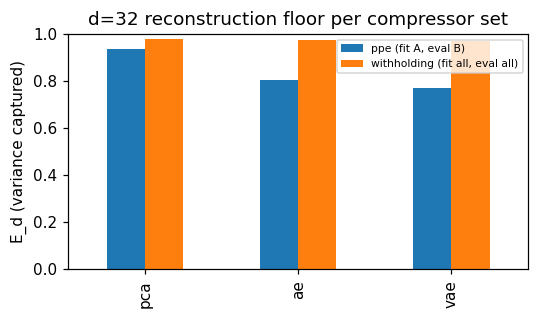

In [4]:
rows = {}
for name in PPE_SET:
    p, w = PPE_SET[name]["comp"], WH_SET[name]["comp"]
    truth_anom = cube_anom_a[truth_idx]              # the held-out truths, in the PPE frame
    rows[name] = {
        "ppe (fit A, eval B)": compute_E_d(truth_anom, p.decode(p.encode(truth_anom)), safe_a),
        "withholding (fit all, eval all)": compute_E_d(
            cube_anom_all, w.decode(w.encode(cube_anom_all)), safe_all),
    }
floor = pd.DataFrame(rows).T
display(floor.round(4))

fig, ax = plt.subplots(figsize=(5, 3))
floor.plot.bar(ax=ax); ax.set_ylim(0, 1); ax.set_ylabel("E_d (variance captured)")
ax.set_title("d=32 reconstruction floor per compressor set")
ax.legend(fontsize=7)
fig.tight_layout(); fig.savefig(FIG / "reconstruction_floor.png", bbox_inches="tight"); plt.show()

## Run the latent matrix

For each method: the same-model PPE on the PPE set (older-half prior, younger-half
truths) and the real-proxy withholding lane on the withholding set (all-ages prior),
climatological background only. Each analysis is a one-step latent gain.

In [5]:
N_NOISE = 5
SOLVER = {"pca": {}, "ae": {"device": DEVICE}, "vae": {"device": DEVICE}}

def factory(cset, name):
    d = cset[name]
    skw = SOLVER[name]
    return lambda prior, shape: latent_var(d["comp"], d["B_z"], d["z_clim"],
                                           shape, prior.safe_valid, **skw)

for name in PPE_SET:
    d = OUT / f"3dvar_{name}"
    if d.exists():
        shutil.rmtree(d)
    print(f"[{name}] ppe")
    ex.run_ppe(cube, ages, lats, lons, valid, long_ppe, str(d),
               make_method=factory(PPE_SET, name), space=name,
               n_noise=N_NOISE, truth_stride=TRUTH_STRIDE, progress_every=5)
    print(f"[{name}] withholding random")
    ex.run_withholding(cube, ages, lats, lons, valid, long_wh, str(d),
                       make_method=factory(WH_SET, name), space=name,
                       fold_kind="random", progress_every=1)
    print("done", name)

[pca] ppe
  truth 5/41 (12%, elapsed 1s, eta 4s)
  truth 10/41 (24%, elapsed 1s, eta 3s)
  truth 15/41 (37%, elapsed 2s, eta 3s)
  truth 20/41 (49%, elapsed 2s, eta 2s)
  truth 25/41 (61%, elapsed 3s, eta 2s)
  truth 30/41 (73%, elapsed 3s, eta 1s)
  truth 35/41 (85%, elapsed 4s, eta 1s)
  truth 40/41 (98%, elapsed 4s, eta 0s)
[pca] withholding random
  sel-fold 1/5 (20%, elapsed 5s, eta 20s)
  sel-fold 2/5 (40%, elapsed 10s, eta 15s)
  sel-fold 3/5 (60%, elapsed 15s, eta 10s)
  sel-fold 4/5 (80%, elapsed 20s, eta 5s)
  sel-fold 5/5 (100%, elapsed 24s, eta 0s)
  test-fold 1/5 (20%, elapsed 5s, eta 21s)
  test-fold 2/5 (40%, elapsed 10s, eta 16s)
  test-fold 3/5 (60%, elapsed 16s, eta 10s)
  test-fold 4/5 (80%, elapsed 21s, eta 5s)
  test-fold 5/5 (100%, elapsed 26s, eta 0s)
done pca
[ae] ppe
  truth 5/41 (12%, elapsed 2s, eta 12s)
  truth 10/41 (24%, elapsed 3s, eta 10s)
  truth 15/41 (37%, elapsed 5s, eta 9s)
  truth 20/41 (49%, elapsed 7s, eta 7s)
  truth 25/41 (61%, elapsed 9s, eta 